<a href="https://colab.research.google.com/github/batireeduienkh6-source/2026_tues_bigdatacomputing_class/blob/main/%EC%A4%91%EA%B0%84%EA%B3%A0%EC%82%AC_%EA%B3%BC%EC%A0%9C_20250068.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# [중간고사 실기 과제] 시계열 기상 데이터 통합 분석 파이프라인 구축
1. 과제 개요

  - 본 과제는 실무 데이터 분석 프로세스를 경험하기 위해 웹상의 기상 데이터를 수집하고, 이를 기계학습 모델링이 가능한 형태의 '깨끗한 데이터'로 가공하는 통합 분석 파이프라인을 개별 함수 단위로 구현하기.

2. 데이터 소스

  - URL: https://github.com/dongupak/DataML/raw/main/csv/weather.csv

  - 주요 컬럼: 지점, 일시, 평균기온, 최대풍속, 평균풍속

3. 핵심 요구 사항 (평가 기준)

  - 모듈화 설계:
    - 모든 기능은 독립적인 함수로 작성되어야 하고,
    - main() 함수에서 제어되어야 함.

  - 데이터 정규화 (Min-Max Scaling):
    - 특정 수치 데이터를 0과 1 사이로 변환하는 함수를 포함해야 함.

  - 시계열 핸들링:
    - 날짜 변환, 인덱스 설정 및 7일 이동 평균 추세선을 생성해야 함.

  - 데이터 재구조화:
    - pivot_table과 groupby를 활용하여 다차원적인 통계량을 산출해야 함.

  - 엑셀 내보내기 (To Excel):
    - 분석 결과인 전처리 데이터, 계절별 통계, 연도별 피벗 테이블을 하나의 엑셀 파일(weather_analysis_report.xlsx)의 별도 시트에 각각 저장해야 함.

  - 다음과 같은 데이터분석 그래프을 생성해야 함.
  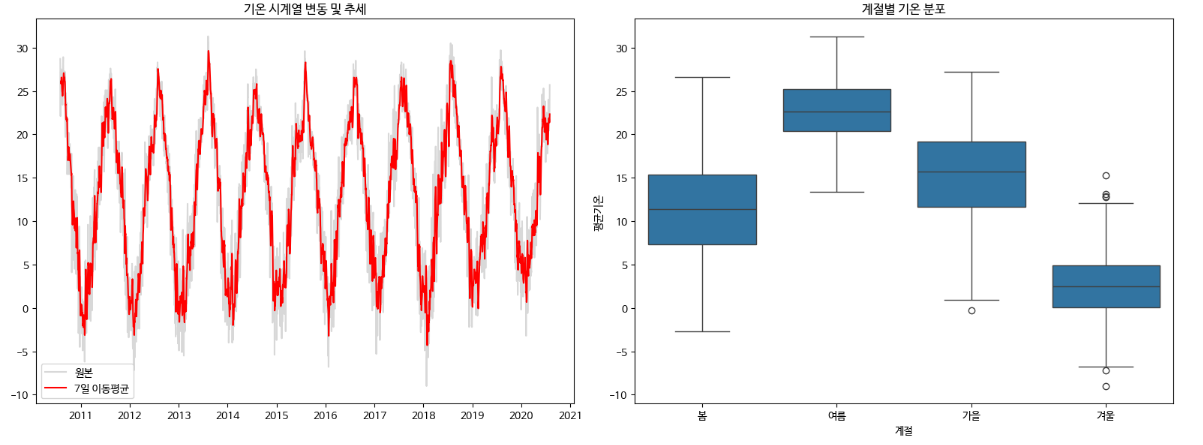

  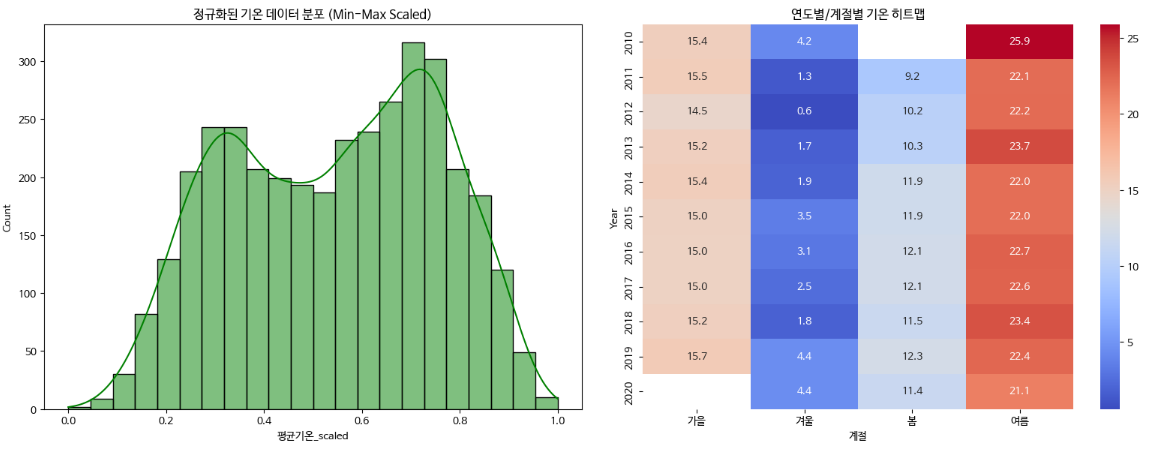



In [ ]:
!apt-get install -y fonts-nanum

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 2 not upgraded.


In [ ]:
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

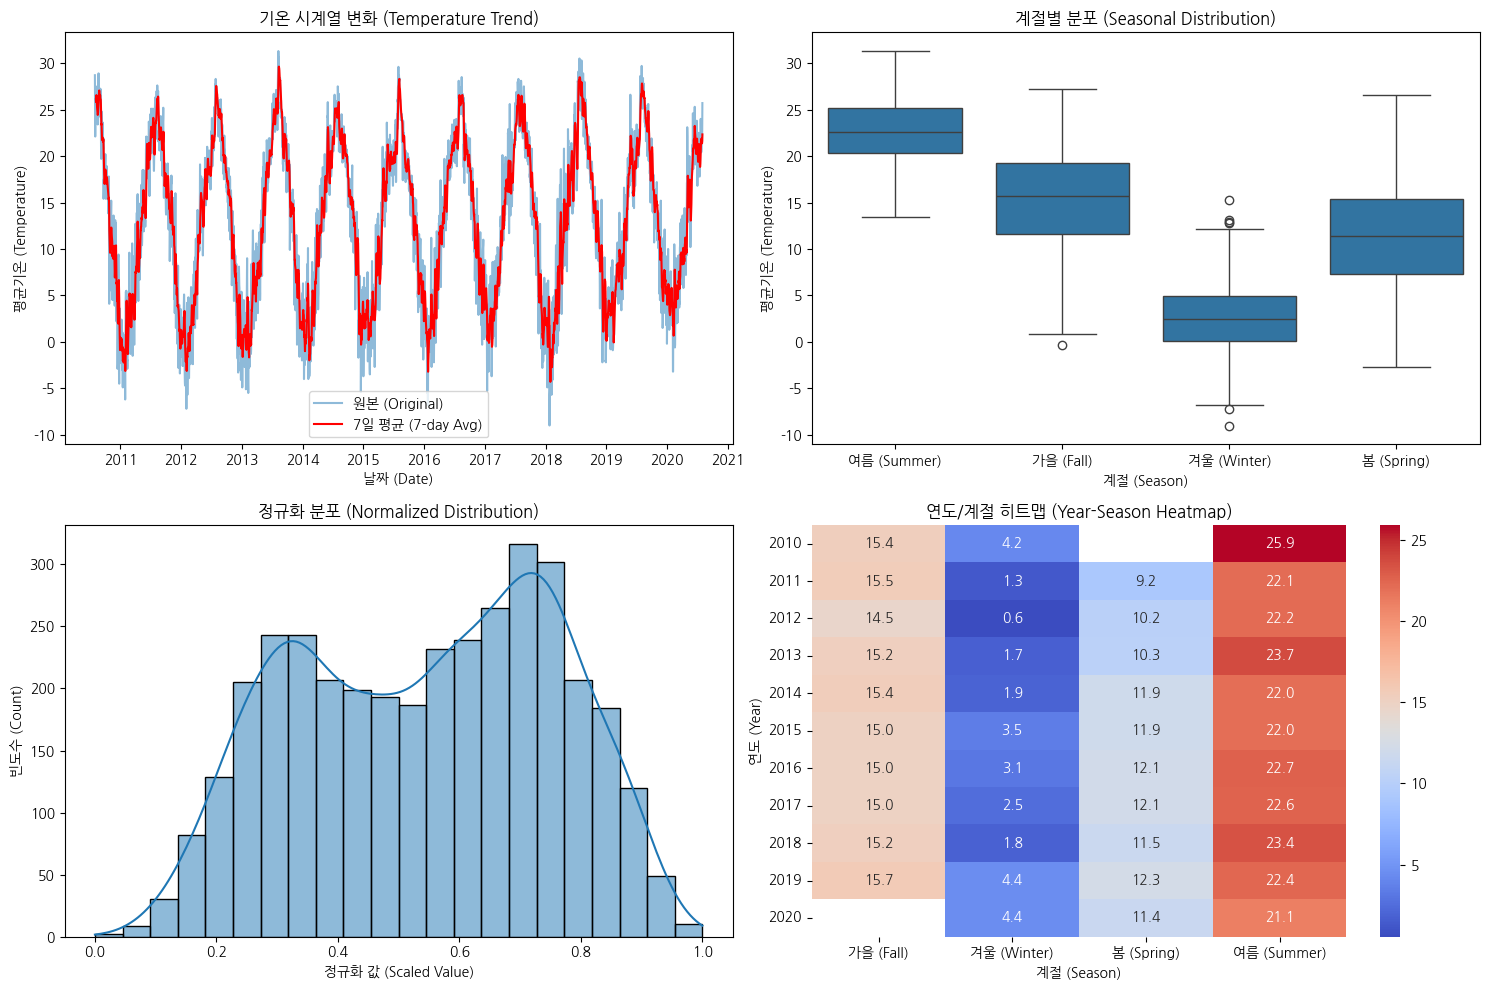

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# 데이터
url = "https://github.com/dongupak/DataML/raw/main/csv/weather.csv"
df = pd.read_csv(url, encoding='cp949')

# 전처리
df['일시'] = pd.to_datetime(df['일시'])
df.set_index('일시', inplace=True)

def season(m):
    if m in [3,4,5]: return '봄 (Spring)'
    elif m in [6,7,8]: return '여름 (Summer)'
    elif m in [9,10,11]: return '가을 (Fall)'
    else: return '겨울 (Winter)'

df['계절'] = df.index.month.map(season)
df['7일 이동평균'] = df['평균기온'].rolling(7).mean()

scaled = (df['평균기온'] - df['평균기온'].min()) / (df['평균기온'].max() - df['평균기온'].min())

df['연도'] = df.index.year
pivot = df.pivot_table(values='평균기온', index='연도', columns='계절', aggfunc='mean')

# 그래프
plt.figure(figsize=(15,10))

# 1
plt.subplot(2,2,1)
plt.plot(df['평균기온'], alpha=0.5)
plt.plot(df['7일 이동평균'], color='red')
plt.title('기온 시계열 변화 (Temperature Trend)')
plt.xlabel('날짜 (Date)')
plt.ylabel('평균기온 (Temperature)')
plt.legend(['원본 (Original)', '7일 평균 (7-day Avg)'])

# 2
plt.subplot(2,2,2)
sns.boxplot(x='계절', y='평균기온', data=df)
plt.title('계절별 분포 (Seasonal Distribution)')
plt.xlabel('계절 (Season)')
plt.ylabel('평균기온 (Temperature)')

# 3
plt.subplot(2,2,3)
sns.histplot(scaled, kde=True)
plt.title('정규화 분포 (Normalized Distribution)')
plt.xlabel('정규화 값 (Scaled Value)')
plt.ylabel('빈도수 (Count)')

# 4
plt.subplot(2,2,4)
sns.heatmap(pivot, annot=True, fmt=".1f", cmap='coolwarm')
plt.title('연도/계절 히트맵 (Year-Season Heatmap)')
plt.xlabel('계절 (Season)')
plt.ylabel('연도 (Year)')

plt.tight_layout()
plt.show()

# Excel
season_stats = df.groupby('계절')['평균기온'].describe()

with pd.ExcelWriter('weather_analysis_report.xlsx') as writer:
    df.to_excel(writer, sheet_name='데이터 (Data)')
    pivot.to_excel(writer, sheet_name='피벗 (Pivot)')
    season_stats.to_excel(writer, sheet_name='계절통계 (Season Stats)')